<a href="https://colab.research.google.com/github/nicolastibata/MINE_4206_AML_202610/blob/main/labs/lab_4/MINE_4206_AML_202610_L4_S1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo AML](https://github.com/nicolastibata/MINE_4206_AML_202610/blob/main/docs/logo.jpg?raw=true)

# **Laboratorio 4 - Sesión 1: Caso de despliegue**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=webpLxVNHcMH&line=9&uniqifier=1)<br>
[1. Introducción de los datos](#scrollTo=1k_rGw_kIdly&line=1&uniqifier=1)<br>
[2. Preparación y Modelamiento](#scrollTo=q4EGraLERzbL&line=1&uniqifier=1)<br>
[3. Despliegue](#scrollTo=4OX8uqI8KdqJ&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- En este problema se busca predecir la probabilidad de fraude en diferentes prestamos basados en su historial crediticio.

**Objetivos**
1. Explorar el dataset para entender las variables y relaizar pruebas de significancia.
2. Preprocesar los datos para preparar las características de entrada y la variable objetivo para el modelado.
3. Probar diferentes modelos de clasificación y desplegar el modelo ajustado.

**Datos**

Los datos al no ser publicos no pueden ser publicados, pero encuentran una muestra [aquí](https://www.kaggle.com/datasets/ruchikakumbhar/obesity-prediction).

### **1. Introducción a los datos**

In [1]:
# Process data and visuals
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style="whitegrid")
import shap

# Statistics
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc, roc_auc_score, PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split, validation_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,  OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, label_binarize
from sklearn.svm import SVC
from xgboost import XGBClassifier
from xgboost import plot_importance
import joblib
import pickle

#### **Exploración**

In [ ]:
df = pd.read_csv("/content/FraudData (March 2026).xlsx - FraudData.csv")
print(df.info())
print(f"\nProportion of empty values:\n{df.isna().sum()/len(df)*100}")
print(f"\nDuplicates?\n{df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   LoanID                307511 non-null  int64  
 1   Fraud                 307511 non-null  int64  
 2   Loan Provider         307511 non-null  object 
 3   Gender                307511 non-null  object 
 4   OwnsCar               307511 non-null  int64  
 5   OwnsProperty          307511 non-null  int64  
 6   NumberOfChildren      307511 non-null  int64  
 7   AnnualIncome          307511 non-null  float64
 8   TotalCredit           307511 non-null  float64
 9   MonthlyPayments       307499 non-null  float64
 10  SecurityDeposit       307233 non-null  float64
 11  LatePaymentAmount     307511 non-null  int64  
 12  Occupation            307511 non-null  object 
 13  Education             307511 non-null  object 
 14  RiskLevel             201725 non-null  object 
 15  

##### **Variables numéricas**

In [ ]:
numerical = df.select_dtypes(include=['int64', 'float64'])
numerical.head()

,LoanID,Fraud,OwnsCar,OwnsProperty,NumberOfChildren,AnnualIncome,TotalCredit,MonthlyPayments,SecurityDeposit,LatePaymentAmount,NumberOfAccounts,CreditScore,CustomerAge,IncomeTaxDefault,NumberOfBankAccounts,HourOfDayApplied,ExperianRating
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,70850,23,212,41,0,35,10,260.6
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,51288,12,416,55,0,12,11,423.8
2,100004,0,1,1,0,67500.0,135000.0,6750.0,135000.0,74388,16,651,74,1,15,9,611.8
3,100006,0,0,1,0,135000.0,312682.5,29686.5,297000.0,170,1,727,47,1,12,17,672.6
4,100007,0,0,1,0,121500.0,513000.0,21865.5,513000.0,54671,0,643,65,0,32,11,605.4


In [ ]:
# Select numerical columns and then nunique
unique_counts = df[numerical.columns].nunique()
print(unique_counts)

# (1) It's normal high nunique counts on numerical, but LoanID doesn't give any info to the future model, then we drop that column

# (2) 'Fraud', 'OwnsCar', 'OwnsProperty', "IncomeTaxDefault" are 0's or 1's value, that is a binary value

LoanID                  307511
Fraud                        2
OwnsCar                      2
OwnsProperty                 2
NumberOfChildren            15
AnnualIncome              2548
TotalCredit               5603
MonthlyPayments          13672
SecurityDeposit           1002
LatePaymentAmount        80019
NumberOfAccounts            24
CreditScore                801
CustomerAge                 51
IncomeTaxDefault             2
NumberOfBankAccounts        45
HourOfDayApplied            24
ExperianRating             801
dtype: int64


In [ ]:
df[numerical.columns].describe()

# (3) A vast difference in number ranges, this will give problems assinging weights (importance) to the features, will need a
# Standard Scaler to have the same distribution without bias

,LoanID,Fraud,OwnsCar,OwnsProperty,NumberOfChildren,AnnualIncome,TotalCredit,MonthlyPayments,SecurityDeposit,LatePaymentAmount,NumberOfAccounts,CreditScore,CustomerAge,IncomeTaxDefault,NumberOfBankAccounts,HourOfDayApplied,ExperianRating
count,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,0.340108,0.693673,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,42516.130288,11.450241,379.204832,51.498581,0.283164,23.064463,12.063419,394.363865
std,102790.175348,0.272419,0.473746,0.460968,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,23508.619626,6.630378,233.238611,13.420738,0.450536,12.983390,3.265832,186.590889
min,100002.000000,0.000000,0.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000000,0.000000,0.000000,25.000000,0.000000,1.000000,0.000000,91.000000
25%,189145.500000,0.000000,0.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,22263.000000,6.000000,175.000000,40.000000,0.000000,12.000000,10.000000,231.000000
50%,278202.000000,0.000000,0.000000,1.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,43840.000000,12.000000,364.000000,51.000000,0.000000,23.000000,12.000000,382.200000
75%,367142.500000,0.000000,1.000000,1.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,62801.500000,17.000000,582.000000,63.000000,1.000000,34.000000,14.000000,556.600000
max,456255.000000,1.000000,1.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,82000.000000,23.000000,800.000000,75.000000,1.000000,45.000000,23.000000,731.000000


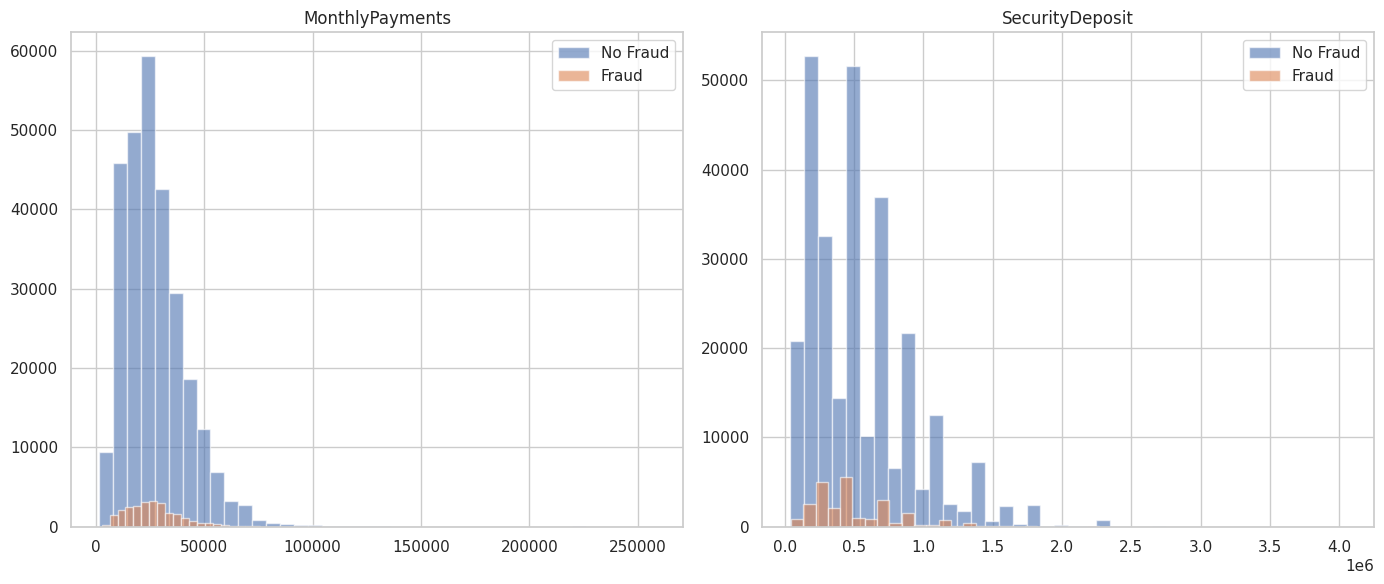

In [ ]:
nan_columns = ['MonthlyPayments', 'SecurityDeposit']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes.flatten(), nan_columns):
    df[df['Fraud']==0][col].hist(ax=ax, bins=40, alpha=0.6, label='No Fraud')
    df[df['Fraud']==1][col].hist(ax=ax, bins=40, alpha=0.6, label='Fraud')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

A subtle left bias, then the imputer is median and not mean

Fraud
0    282686
1     24825
Name: count, dtype: int64
Fraud
0    0.919271
1    0.080729
Name: proportion, dtype: float64


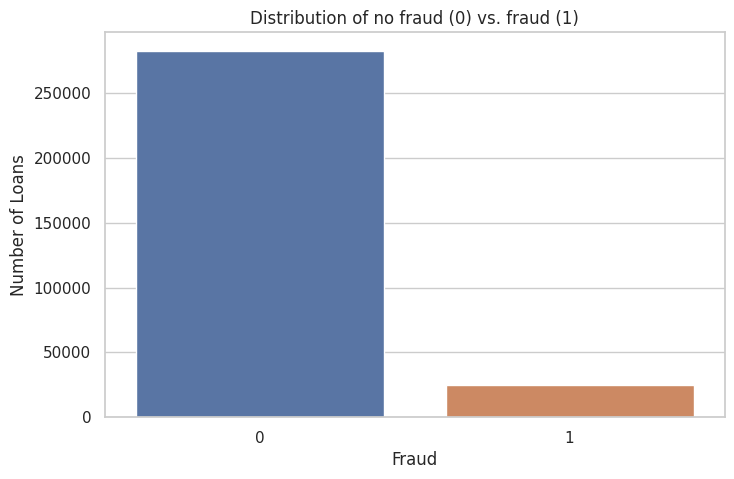

In [ ]:
print(df['Fraud'].value_counts())
print(df['Fraud'].value_counts(normalize=True))

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Fraud', data=df, legend=False, hue='Fraud')
plt.title('Distribution of no fraud (0) vs. fraud (1)')
plt.ylabel('Number of Loans')
plt.show()
# Imbalanced class, 91% is no fraud

In [ ]:
# We must compare the numerical columns by class
df.groupby('Fraud')[numerical.columns].mean()

,LoanID,Fraud,OwnsCar,OwnsProperty,NumberOfChildren,AnnualIncome,TotalCredit,MonthlyPayments,SecurityDeposit,LatePaymentAmount,NumberOfAccounts,CreditScore,CustomerAge,IncomeTaxDefault,NumberOfBankAccounts,HourOfDayApplied,ExperianRating
Fraud,,,,,,,,,,,,,,,,,
0,278244.744536,0.0,0.343176,0.694513,0.412946,169077.722266,602648.282002,27163.623349,542736.795003,40983.307964,11.008451,399.374302,52.503152,0.249478,23.061467,12.086807,410.499442
1,277449.167936,1.0,0.305176,0.684109,0.463807,165611.760906,557778.527674,26481.744290,488972.412554,59970.608097,16.480967,149.532044,40.059376,0.666747,23.098570,11.797100,210.625635


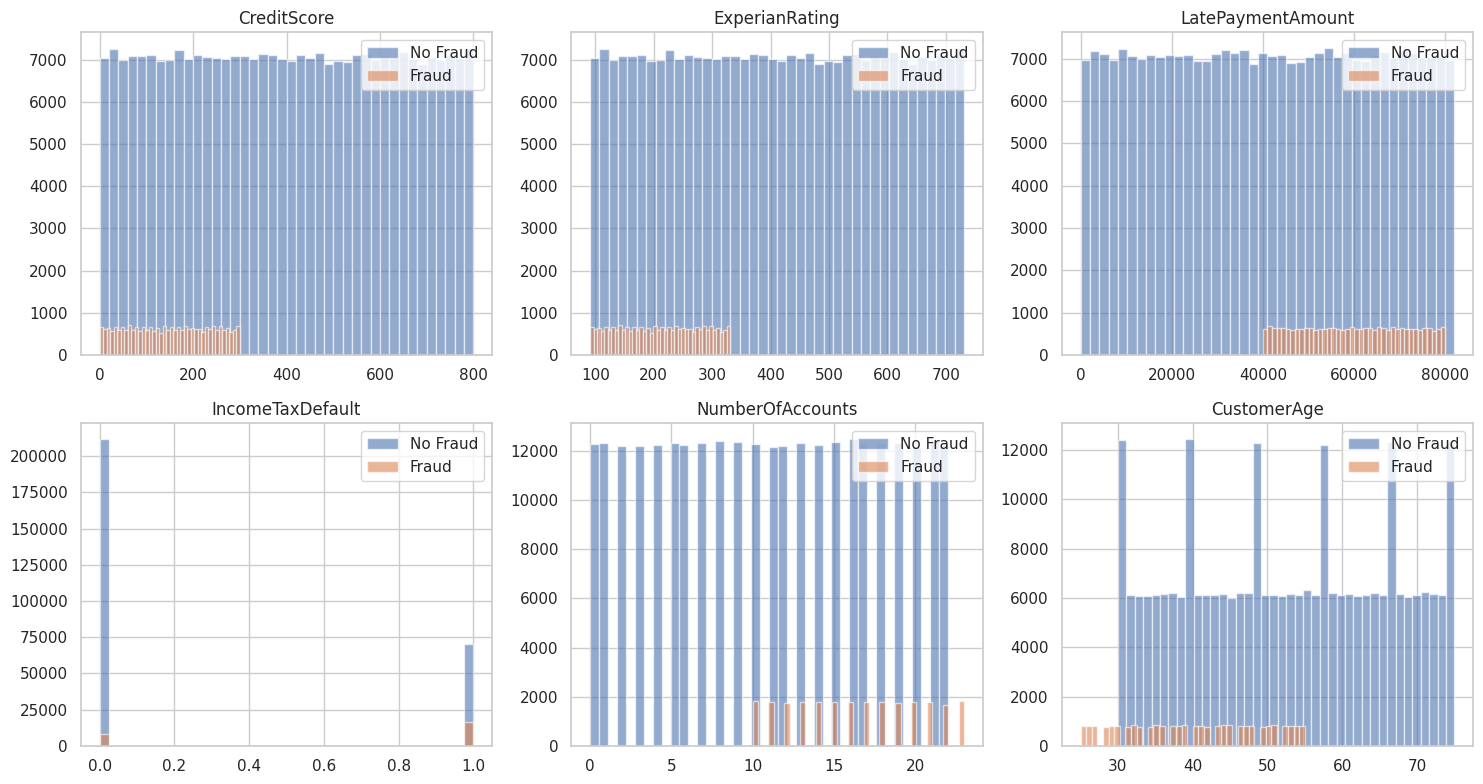

In [ ]:
strong_changes = ['CreditScore', 'ExperianRating', 'LatePaymentAmount',
                  'IncomeTaxDefault', 'NumberOfAccounts', 'CustomerAge']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), strong_changes):
    df[df['Fraud']==0][col].hist(ax=ax, bins=40, alpha=0.6, label='No Fraud')
    df[df['Fraud']==1][col].hist(ax=ax, bins=40, alpha=0.6, label='Fraud')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

This shows how these variables are important and how they define the future boundaries for the modelling.

In [ ]:
results = []
for col in numerical.columns:
    clean = df[['Fraud', col]].dropna()
    r, p = pointbiserialr(clean['Fraud'], clean[col])
    if isinstance(r, np.ndarray):
        r = r[0]
    if isinstance(p, np.ndarray):
        p = p[0]
    results.append({'Feature': col, 'r': round(r, 4), 'p_value': round(p, 6)})


# Convert to dataframe
results_df = pd.DataFrame(results).sort_values('r', key=abs, ascending=True)
# Filter feature != fraud
results_df = results_df[results_df['Feature'] != 'Fraud']


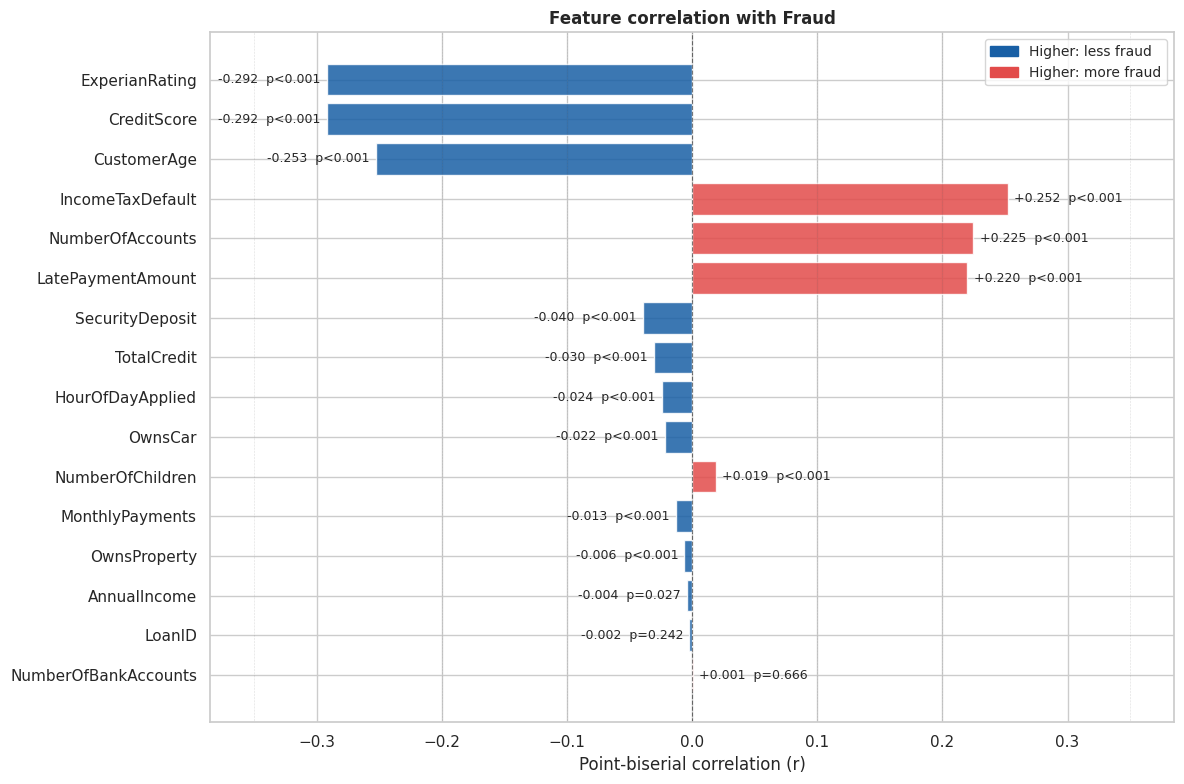

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#E24B4A' if r > 0 else '#185FA5' for r in results_df['r']]
bars = ax.barh(results_df['Feature'], results_df['r'], color=colors, alpha=0.85)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Point-biserial correlation (r)')
ax.set_title('Feature correlation with Fraud', fontweight='bold')

# Annotate bars with r and p value
for bar, r_val, p_val in zip(bars, results_df['r'], results_df['p_value']):
    x = bar.get_width()
    p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
    label = f'{r_val:+.3f}  {p_str}'
    ax.text(x + (0.005 if x >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            label,
            va='center',
            ha='left' if x >= 0 else 'right',
            fontsize=9)

# Reference lines for strength thresholds
for x in [-0.35, -0.2, -0.1, 0.1, 0.2, 0.35]:
    ax.axvline(x, color='gray', linewidth=0.4, linestyle=':', alpha=0.5)

legend = [mpatches.Patch(color='#185FA5', label='Higher: less fraud'),
          mpatches.Patch(color='#E24B4A', label='Higher: more fraud')]
ax.legend(handles=legend, fontsize=10)

plt.tight_layout()
plt.show()

Important inisghts here:
p<0.05. good
1. Check posible redundancy between `ExperianRating` and `CreditScore`, which is more informative?
2. Drop `LoanID` and `NumberOfBankAccounts` (high p-value = random noise)


In [ ]:
print(df[['CreditScore', 'ExperianRating']].corr())
# Measuring the same thing, literally the same effect
# Kept CreditScore such is more easy to interpret and generic in this bussines case

                CreditScore  ExperianRating
CreditScore             1.0             1.0
ExperianRating          1.0             1.0


##### **Variables categóricas**

In [ ]:
categorical = df.select_dtypes(include=['object'])
categorical.head()

,Loan Provider,Gender,Occupation,Education,RiskLevel,MartialStatus,HouseType,ApplicationDay
0,Cash loans,M,Working,Secondary / secondary special,LowRisk,Single / not married,House / apartment,WEDNESDAY
1,Cash loans,F,State servant,Higher education,HighRisk,Married,House / apartment,MONDAY
2,Loans Now,M,Working,Secondary / secondary special,NaN,Single / not married,House / apartment,MONDAY
3,Cash loans,F,Working,Secondary / secondary special,NaN,Civil marriage,House / apartment,WEDNESDAY
4,Cash loans,M,Working,Secondary / secondary special,NaN,Single / not married,House / apartment,THURSDAY


In [ ]:
# data quality checks
for column in categorical.columns:
  print(f"\n{column}: {df[column].value_counts(dropna=False)}")


Loan Provider: Loan Provider
Cash loans    278232
Loans Now      29279
Name: count, dtype: int64

Gender: Gender
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Occupation: Occupation
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

Education: Education
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

RiskLevel: RiskLevel
NaN         105786
Risk         79283
LowRisk      78841
HighRisk     43601
Name: count, dtype: int64

MartialStatus: MartialStatus
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                

In [ ]:
for col in categorical.columns:
    ct = pd.crosstab(df[col], df['Fraud'])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"{col}: chi2={chi2:.1f}, p={p:.4f}")

Loan Provider: chi2=293.2, p=0.0000
Gender: chi2=920.8, p=0.0000
Occupation: chi2=1253.5, p=0.0000
Education: chi2=1019.2, p=0.0000
RiskLevel: chi2=2336.0, p=0.0000
MartialStatus: chi2=504.7, p=0.0000
HouseType: chi2=420.6, p=0.0000
ApplicationDay: chi2=15.4, p=0.0174


In [ ]:
def cramers_v(col):
    ct = pd.crosstab(df[col], df['Fraud'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return chi2, p, round(v, 4)

for col in categorical.columns:
    chi2, p, v = cramers_v(col)
    print(f"{col}: chi2={chi2:.1f}, p={p:.4f}, V={v}")

Loan Provider: chi2=293.2, p=0.0000, V=0.0309
Gender: chi2=920.8, p=0.0000, V=0.0547
Occupation: chi2=1253.5, p=0.0000, V=0.0638
Education: chi2=1019.2, p=0.0000, V=0.0576
RiskLevel: chi2=2336.0, p=0.0000, V=0.1076
MartialStatus: chi2=504.7, p=0.0000, V=0.0405
HouseType: chi2=420.6, p=0.0000, V=0.037
ApplicationDay: chi2=15.4, p=0.0174, V=0.0071


In [ ]:
ct = pd.crosstab(df['Gender'], df['Fraud'], normalize='index') * 100
print(ct.round(2))

Fraud        0      1
Gender               
F        93.00   7.00
M        89.86  10.14
XNA     100.00   0.00


Doesn't show any miss typing or redundant categorization.
But we need to do some changes:
1. `Gender`: Drop XNA (0.001%) data, not representative
2. `Occupation`: Unemployed (22), Student (18), Businessman (10), Maternity leave (5) combined just 55 rows (0.018% of data). Group them to 'Other' to prevent overfitting
3. `MartialStatus`: Drop Unknown (0.001%) data, not representative
4. `RiskLevel`: A LOT of nans, map them.

### **2. Preparación y Modelamiento**

#### **Feature Engineering**

Lets remember the transformations that we need to do:
1. Check posible redundancy between `ExperianRating` and `CreditScore`, which is more informative? Drop `ExperianRating`
2. Drop `LoanID` and `NumberOfBankAccounts` (high p-value = random noise)
3. Standard Scaler to have the same distribution without bias.
4. `Gender`: Drop XNA (0.001%) data, not representative
5. `Occupation`: Unemployed (22), Student (18), Businessman (10), Maternity leave (5) combined just 55 rows (0.018% of data). Group them to 'Other' to prevent overfitting
6. `MartialStatus`: Drop Unknown (0.001%) data, not representative
7. `RiskLevel`: A LOT of nans, map them.
8. OneHot encoder to non Ordinal values, then ordinal encoder

In [ ]:
df_model = df.copy()
train_data, test_data = train_test_split(df_model, test_size=0.2, random_state=71, stratify=df_model['Fraud'])
print(train_data.shape)
print(test_data.shape)

(246008, 25)
(61503, 25)


In [ ]:
def filter_cols(df):
  df = df.copy()
  df = df[df['MartialStatus'] != 'Unknown'].reset_index(drop=True)
  df = df[df['Gender'] != 'XNA'].reset_index(drop=True)
  df['Occupation'] = df['Occupation'].replace(['Unemployed', 'Student', 'Businessman', 'Maternity leave'], 'Other')
  df['RiskLevel'] = df['RiskLevel'].fillna('Unknown')
  print(f"Duplicates found: {df.duplicated().sum().sum()}")
  df = df.drop_duplicates()
  X, y = df.drop(columns=['Fraud'], axis=1), df['Fraud']
  return X, y


def map_cols(df):
  df = df.copy()
  risk_order = {'LowRisk': 0, 'Risk': 1, 'HighRisk': 2, 'Unknown': -1}
  edu_order = {'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}
  gender_map = {'M': 0, 'F': 1}
  df['RiskLevel'] = df['RiskLevel'].map(risk_order) # Ordinal Encoder
  df['Education'] = df['Education'].map(edu_order) # Ordinal Encoder
  df['Gender']= df['Gender'].map(gender_map)
  return df


def transform_num_cols(df):
  df = df.copy()
  drop_cols = ['LoanID', 'NumberOfBankAccounts', 'ExperianRating']
  df = df.drop(drop_cols, axis = 1)
  return df

In [ ]:
X_train, y_train = filter_cols(train_data)
display(X_train)
display(y_train)

Duplicates found: 0


,LoanID,Loan Provider,Gender,OwnsCar,OwnsProperty,NumberOfChildren,AnnualIncome,TotalCredit,MonthlyPayments,SecurityDeposit,...,MartialStatus,HouseType,NumberOfAccounts,CreditScore,CustomerAge,IncomeTaxDefault,NumberOfBankAccounts,ApplicationDay,HourOfDayApplied,ExperianRating
0,445722,Cash loans,F,0,0,0,112500.0,225000.0,9909.0,225000.0,...,Widow,House / apartment,5,175,50,0,29,MONDAY,10,231.0
1,213831,Cash loans,F,0,1,1,180000.0,277969.5,10606.5,229500.0,...,Married,With parents,15,58,55,0,18,MONDAY,13,137.4
2,312648,Cash loans,F,1,0,1,180000.0,568057.5,27459.0,459000.0,...,Married,House / apartment,16,347,75,0,7,FRIDAY,9,368.6
3,198748,Cash loans,M,1,0,0,218250.0,1687266.0,62527.5,1575000.0,...,Married,House / apartment,20,661,46,0,9,TUESDAY,13,619.8
4,113218,Cash loans,F,0,0,1,202500.0,536917.5,27931.5,463500.0,...,Married,Municipal apartment,22,458,71,0,36,MONDAY,13,457.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245997,277520,Cash loans,F,0,1,0,193500.0,276277.5,23841.0,238500.0,...,Married,House / apartment,3,195,43,1,43,MONDAY,18,247.0
245998,356946,Cash loans,F,1,1,0,112500.0,291915.0,14170.5,252000.0,...,Separated,House / apartment,15,75,62,0,17,FRIDAY,7,151.0
245999,136910,Cash loans,F,0,1,0,112500.0,675000.0,28728.0,675000.0,...,Civil marriage,House / apartment,10,538,73,0,23,MONDAY,13,521.4
246000,313735,Cash loans,F,0,0,0,112500.0,518562.0,21969.0,463500.0,...,Single / not married,House / apartment,12,715,37,0,17,WEDNESDAY,12,663.0


,Fraud
0,0
1,0
2,0
3,0
4,0
...,...
245997,0
245998,0
245999,0
246000,0


In [ ]:
binary_cols = ['OwnsCar', 'OwnsProperty', 'IncomeTaxDefault']
mapped_cols = ['RiskLevel', 'Education', 'Gender']
cat_cols = X_train.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(mapped_cols)
num_cols = X_train.select_dtypes(include=['number']).columns
num_cols = num_cols.difference(binary_cols)
print(cat_cols)
print(num_cols)


Index(['ApplicationDay', 'HouseType', 'Loan Provider', 'MartialStatus',
       'Occupation'],
      dtype='object')
Index(['AnnualIncome', 'CreditScore', 'CustomerAge', 'ExperianRating',
       'HourOfDayApplied', 'LatePaymentAmount', 'LoanID', 'MonthlyPayments',
       'NumberOfAccounts', 'NumberOfBankAccounts', 'NumberOfChildren',
       'SecurityDeposit', 'TotalCredit'],
      dtype='object')


In [ ]:
# Build our pipeline
num_transformer = Pipeline(
    steps=[
      ('transform', FunctionTransformer(transform_num_cols)),
      ('imputer', SimpleImputer(strategy='median')),
      ('scaler', StandardScaler())
])

cat_transformer = Pipeline(
    steps=[
      ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('pass', 'passthrough', mapped_cols + binary_cols)
]).set_output(transform='pandas') # Keep column names


pipe = Pipeline(steps=[
    ('map', FunctionTransformer(map_cols)),
    ('column_transformer', preprocessor)])


In [ ]:
pipe

Pipeline(steps=[('map',
                 FunctionTransformer(func=<function map_cols at 0x7c8382508ea0>)),
                ('column_transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('transform',
                                                                   FunctionTransformer(func=<function transform_num_cols at 0x7c8382508e00>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['AnnualIncome', 'Credi...
       'SecurityDeposit', 'TotalCredit'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['ApplicationDay', 'HouseType', 'Loan Provider', 'MartialStatus',
       'Occupation'],
      dtype='object')),
                                                 ('pass', 'passthrough',
                                                  ['RiskLevel', 'Education',
                                                   'Gender', 'OwnsCar',
                                                   'OwnsProperty',
                                                   'IncomeTaxDefault'])]))])

In [ ]:
pipe.fit_transform(X_train)

,num__AnnualIncome,num__CreditScore,num__CustomerAge,num__HourOfDayApplied,num__LatePaymentAmount,num__MonthlyPayments,num__NumberOfAccounts,num__NumberOfChildren,num__SecurityDeposit,num__TotalCredit,...,cat__Occupation_Other,cat__Occupation_Pensioner,cat__Occupation_State servant,cat__Occupation_Working,pass__RiskLevel,pass__Education,pass__Gender,pass__OwnsCar,pass__OwnsProperty,pass__IncomeTaxDefault
0,-0.218466,-0.875797,-0.111631,-0.633162,1.315539,-1.186756,-0.972782,-0.578372,-0.847692,-0.928537,...,0.0,1.0,0.0,0.0,-1,3,1,0,0,0
1,0.043346,-1.377455,0.261143,0.285440,0.182779,-1.138590,0.535458,0.807244,-0.835503,-0.796904,...,0.0,0.0,0.0,1.0,0,3,1,0,1,0
2,0.043346,-0.138316,1.752240,-0.939362,0.046314,0.025145,0.686281,0.807244,-0.213847,-0.076015,...,0.0,0.0,0.0,0.0,2,1,1,1,0,0
3,0.191706,1.208015,-0.409850,0.285440,-0.166315,2.446771,1.289577,-0.578372,2.809106,2.705299,...,0.0,0.0,0.0,0.0,-1,1,0,1,0,0
4,0.130617,0.337616,1.454021,0.285440,-1.007136,0.057773,1.591225,0.807244,-0.201658,-0.153400,...,0.0,0.0,0.0,0.0,-1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245997,0.095708,-0.790043,-0.633515,1.816443,-0.599398,-0.224693,-1.274430,-0.578372,-0.811124,-0.801109,...,0.0,0.0,0.0,1.0,2,1,1,0,1,1
245998,-0.218466,-1.304565,0.783027,-1.551763,1.378307,-0.892481,0.535458,-0.578372,-0.774556,-0.762249,...,0.0,0.0,0.0,1.0,-1,1,1,1,1,0
245999,-0.218466,0.680630,1.603130,0.285440,0.798128,0.112775,-0.218662,-0.578372,0.371241,0.189745,...,0.0,1.0,0.0,0.0,1,1,1,0,1,0
246000,-0.218466,1.439549,-1.080844,-0.020760,0.435297,-0.353962,0.082986,-0.578372,-0.201658,-0.199015,...,0.0,0.0,0.0,0.0,0,1,1,0,0,0


#### **Modelamiento**

##### **Logistic Regression**

In [ ]:
estimators_lr = [
    ('transform', pipe),
    ('model', LogisticRegression(random_state=71))
]

pipe_lr = Pipeline(estimators_lr)
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 Pipeline(steps=[('map',
                                  FunctionTransformer(func=<function map_cols at 0x7c8382508ea0>)),
                                 ('column_transformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('transform',
                                                                                    FunctionTransformer(func=<function transform_num_cols at 0x7c8382508e00>)),
                                                                                   ('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())])...
      dtype='object')),
                                                                  ('cat',
                                                                   Pipeline(steps=[('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   Index(['ApplicationDay', 'HouseType', 'Loan Provider', 'MartialStatus',
       'Occupation'],
      dtype='object')),
                                                                  ('pass',
                                                                   'passthrough',
                                                                   ['RiskLevel',
                                                                    'Education',
                                                                    'Gender',
                                                                    'OwnsCar',
                                                                    'OwnsProperty',
                                                                    'IncomeTaxDefault'])]))])),
                ('model', LogisticRegression(random_state=71))])

In [ ]:
y_pred_train = pipe_lr.predict(X_train)
y_pred_train

array([0, 0, 0, ..., 0, 0, 0])

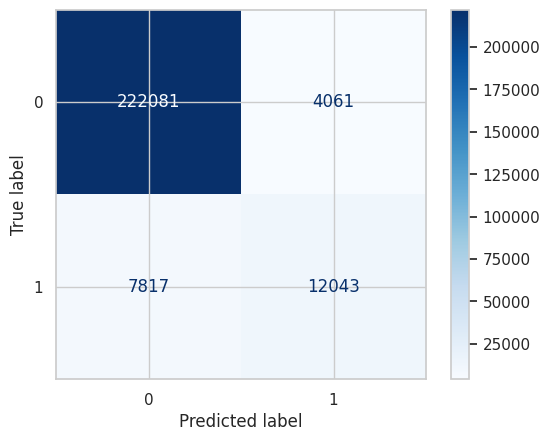

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, cmap='Blues')
plt.show()

In [ ]:
train_report = classification_report(y_train, y_pred_train)
print("Train Report for Logistic Regression\n", train_report)

Train Report for Logistic Regression
               precision    recall  f1-score   support

           0       0.97      0.98      0.97    226142
           1       0.75      0.61      0.67     19860

    accuracy                           0.95    246002
   macro avg       0.86      0.79      0.82    246002
weighted avg       0.95      0.95      0.95    246002



**Evaluate model**

In [ ]:
X_test, y_test = filter_cols(test_data)

Duplicates found: 0


In [ ]:
y_pred_test = pipe_lr.predict(X_test)
y_pred_test

array([0, 0, 0, ..., 0, 0, 0])

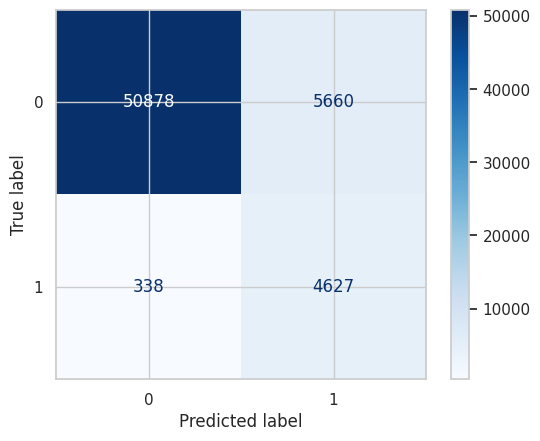

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues')
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test)
print("Test Report for Logistic Regression\n", test_report)

Test Report for Logistic Regression
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     56538
           1       0.45      0.93      0.61      4965

    accuracy                           0.90     61503
   macro avg       0.72      0.92      0.78     61503
weighted avg       0.95      0.90      0.92     61503



**Not overfitting, but not the best model.**

##### **Random Forest**

In [ ]:
estimators_rf = [
    ('transform', pipe),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=71, n_jobs=-1))
]

pipe_rf = Pipeline(estimators_rf)
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 Pipeline(steps=[('map',
                                  FunctionTransformer(func=<function map_cols at 0x7c8382508ea0>)),
                                 ('column_transformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('transform',
                                                                                    FunctionTransformer(func=<function transform_num_cols at 0x7c8382508e00>)),
                                                                                   ('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())])...
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   Index(['ApplicationDay', 'HouseType', 'Loan Provider', 'MartialStatus',
       'Occupation'],
      dtype='object')),
                                                                  ('pass',
                                                                   'passthrough',
                                                                   ['RiskLevel',
                                                                    'Education',
                                                                    'Gender',
                                                                    'OwnsCar',
                                                                    'OwnsProperty',
                                                                    'IncomeTaxDefault'])]))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=3,
                                        n_jobs=-1, random_state=71))])

In [ ]:
y_pred_train_rf = pipe_rf.predict(X_train)
y_pred_train_rf

array([0, 1, 0, ..., 0, 0, 0])

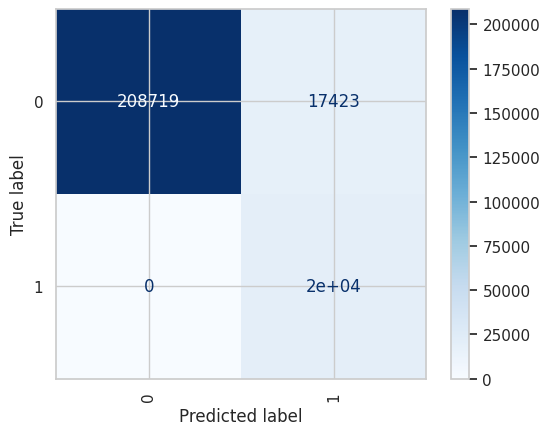

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_rf, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
train_report = classification_report(y_train, y_pred_train_rf)
print("Train Report for Random Forest\n", train_report)

Train Report
               precision    recall  f1-score   support

           0       1.00      0.92      0.96    226142
           1       0.53      1.00      0.70     19860

    accuracy                           0.93    246002
   macro avg       0.77      0.96      0.83    246002
weighted avg       0.96      0.93      0.94    246002



**Evaluate model**

In [ ]:
y_pred_test_rf = pipe_rf.predict(X_test)
y_pred_test_rf

array([0, 0, 0, ..., 0, 0, 0])

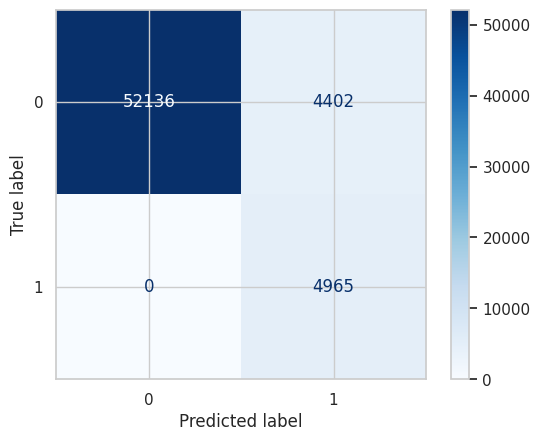

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_rf, cmap='Blues')
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test_rf)
print("Test Report for Random Forest\n", test_report)

Test Report for Random Forest
               precision    recall  f1-score   support

           0       1.00      0.92      0.96     56538
           1       0.53      1.00      0.69      4965

    accuracy                           0.93     61503
   macro avg       0.77      0.96      0.83     61503
weighted avg       0.96      0.93      0.94     61503



**Good model**

##### **XGBoost**

In [ ]:
# Class imbalance ratio for XGBoost
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {fraud_ratio:.1f}")


estimators_xgb = [
    ('transform', pipe),
    ('model', XGBClassifier(scale_pos_weight=fraud_ratio, n_estimators=300, learning_rate=0.05, max_depth=5,
              random_state=71,eval_metric='aucpr',n_jobs=-1))
]

pipe_xgb = Pipeline(estimators_xgb)
pipe_xgb.fit(X_train, y_train)

scale_pos_weight: 11.4


Pipeline(steps=[('transform',
                 Pipeline(steps=[('map',
                                  FunctionTransformer(func=<function map_cols at 0x7c8382508ea0>)),
                                 ('column_transformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('transform',
                                                                                    FunctionTransformer(func=<function transform_num_cols at 0x7c8382508e00>)),
                                                                                   ('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())])...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_train_xgb = pipe_xgb.predict(X_train)
y_pred_train_xgb

array([0, 1, 0, ..., 0, 0, 0])

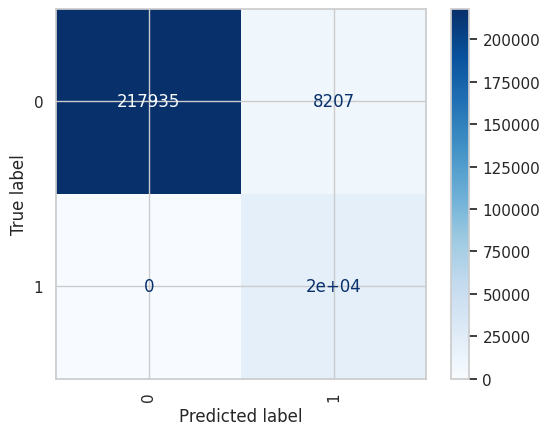

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_xgb, cmap='Blues')
plt.xticks(rotation=90)
plt.show()

In [ ]:
train_report = classification_report(y_train, y_pred_train_xgb)
print("Train Report for XGBoost\n", train_report)

Train Report
               precision    recall  f1-score   support

           0       1.00      0.96      0.98    226142
           1       0.71      1.00      0.83     19860

    accuracy                           0.97    246002
   macro avg       0.85      0.98      0.91    246002
weighted avg       0.98      0.97      0.97    246002



**Evaluate model**

In [ ]:
y_pred_test_xgb = pipe_xgb.predict(X_test)
y_pred_test_xgb

array([0, 0, 0, ..., 0, 0, 0])

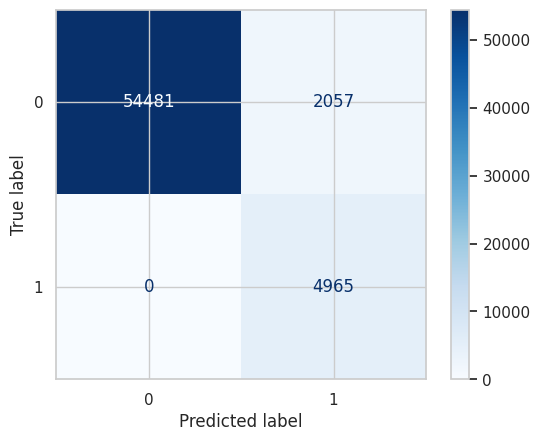

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_xgb, cmap='Blues')
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test_xgb)
print("Test Report for XGBoost\n", test_report)

Test Report for XGBoost
               precision    recall  f1-score   support

           0       1.00      0.96      0.98     56538
           1       0.71      1.00      0.83      4965

    accuracy                           0.97     61503
   macro avg       0.85      0.98      0.90     61503
weighted avg       0.98      0.97      0.97     61503



**Same basics as Random Forest, faster and better results with no overfitting.**

##### **Fine Tuned XGBoost**

In [ ]:
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()

param_dist = {
    'model__n_estimators':      [200, 300, 400, 500],
    'model__max_depth':         [3, 4, 5, 6],
    'model__learning_rate':     [0.01, 0.05, 0.1],
    'model__subsample':         [0.7, 0.8, 0.9],
    'model__colsample_bytree':  [0.7, 0.8, 0.9],
    'model__min_child_weight':  [1, 5, 10, 20],
    'model__gamma':             [0, 0.1, 0.5, 1],
    'model__reg_alpha':         [0, 0.1, 1],       # L1 regularisation
    'model__reg_lambda':        [1, 2, 5],          # L2 regularisation
    'model__scale_pos_weight':  [fraud_ratio * 0.5,
                                 fraud_ratio * 0.75,
                                 fraud_ratio]       # lower weights: higher precision but lower recall (trade-off)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=71)

search = RandomizedSearchCV(
    pipe_xgb,                    # full pipeline including preprocessing
    param_distributions=param_dist,
    n_iter=50,                   # stop at 50, keep best model
    scoring='f1',                # optimise for fraud F1
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=71
)

In [ ]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('transform',
                                              Pipeline(steps=[('map',
                                                               FunctionTransformer(func=<function map_cols at 0x7c8382508ea0>)),
                                                              ('column_transformer',
                                                               ColumnTransformer(transformers=[('num',
                                                                                                Pipeline(steps=[('transform',
                                                                                                                 FunctionTransformer(func=<function transform_num_cols at 0x7...
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [1, 5, 10,
                                                                    20],
                                        'model__n_estimators': [200, 300, 400,
                                                                500],
                                        'model__reg_alpha': [0, 0.1, 1],
                                        'model__reg_lambda': [1, 2, 5],
                                        'model__scale_pos_weight': [np.float64(5.693403826787512),
                                                                    np.float64(8.540105740181268),
                                                                    np.float64(11.386807653575024)],
                                        'model__subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
best_model = search.best_estimator_
search.best_params_

{'model__subsample': 0.7,
 'model__scale_pos_weight': np.float64(5.693403826787512),
 'model__reg_lambda': 5,
 'model__reg_alpha': 0,
 'model__n_estimators': 300,
 'model__min_child_weight': 10,
 'model__max_depth': 5,
 'model__learning_rate': 0.1,
 'model__gamma': 1,
 'model__colsample_bytree': 0.9}

In [ ]:
y_pred_train_bm = best_model.predict(X_train)
y_pred_train_bm

array([0, 1, 0, ..., 0, 0, 0])

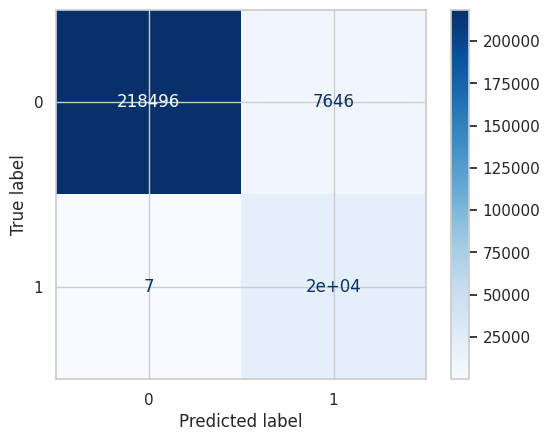

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_bm, cmap='Blues')
plt.show()

In [ ]:
train_report = classification_report(y_train, y_pred_train_bm)
print("Train Report for fine tuned XGBoost\n", train_report)

Train Report for fine tuned XGBoost
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    226142
           1       0.72      1.00      0.84     19860

    accuracy                           0.97    246002
   macro avg       0.86      0.98      0.91    246002
weighted avg       0.98      0.97      0.97    246002



**Evaluate fine tuned model**

In [ ]:
y_pred_test_bm = best_model.predict(X_test)
y_pred_test_bm

array([0, 0, 0, ..., 0, 0, 0])

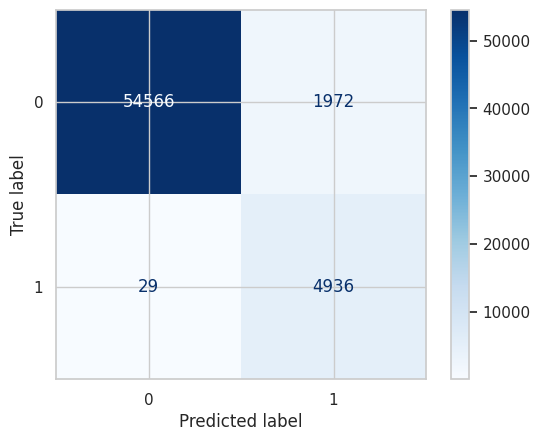

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_bm, cmap='Blues')
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test_bm)
print("Test Report for fine tuned XBoost\n", test_report)

Test Report for fine tuned XBoost
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     56538
           1       0.71      0.99      0.83      4965

    accuracy                           0.97     61503
   macro avg       0.86      0.98      0.91     61503
weighted avg       0.98      0.97      0.97     61503



#### **Resultados:**


In [ ]:
best_model

Pipeline(steps=[('transform',
                 Pipeline(steps=[('map',
                                  FunctionTransformer(func=<function map_cols at 0x7c8382508ea0>)),
                                 ('column_transformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('transform',
                                                                                    FunctionTransformer(func=<function transform_num_cols at 0x7c8382508e00>)),
                                                                                   ('imputer',
                                                                                    SimpleImputer(strategy='median')),
                                                                                   ('scaler',
                                                                                    StandardScaler())])...
                               feature_types=None, feature_weights=None,
                               gamma=1, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=10, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

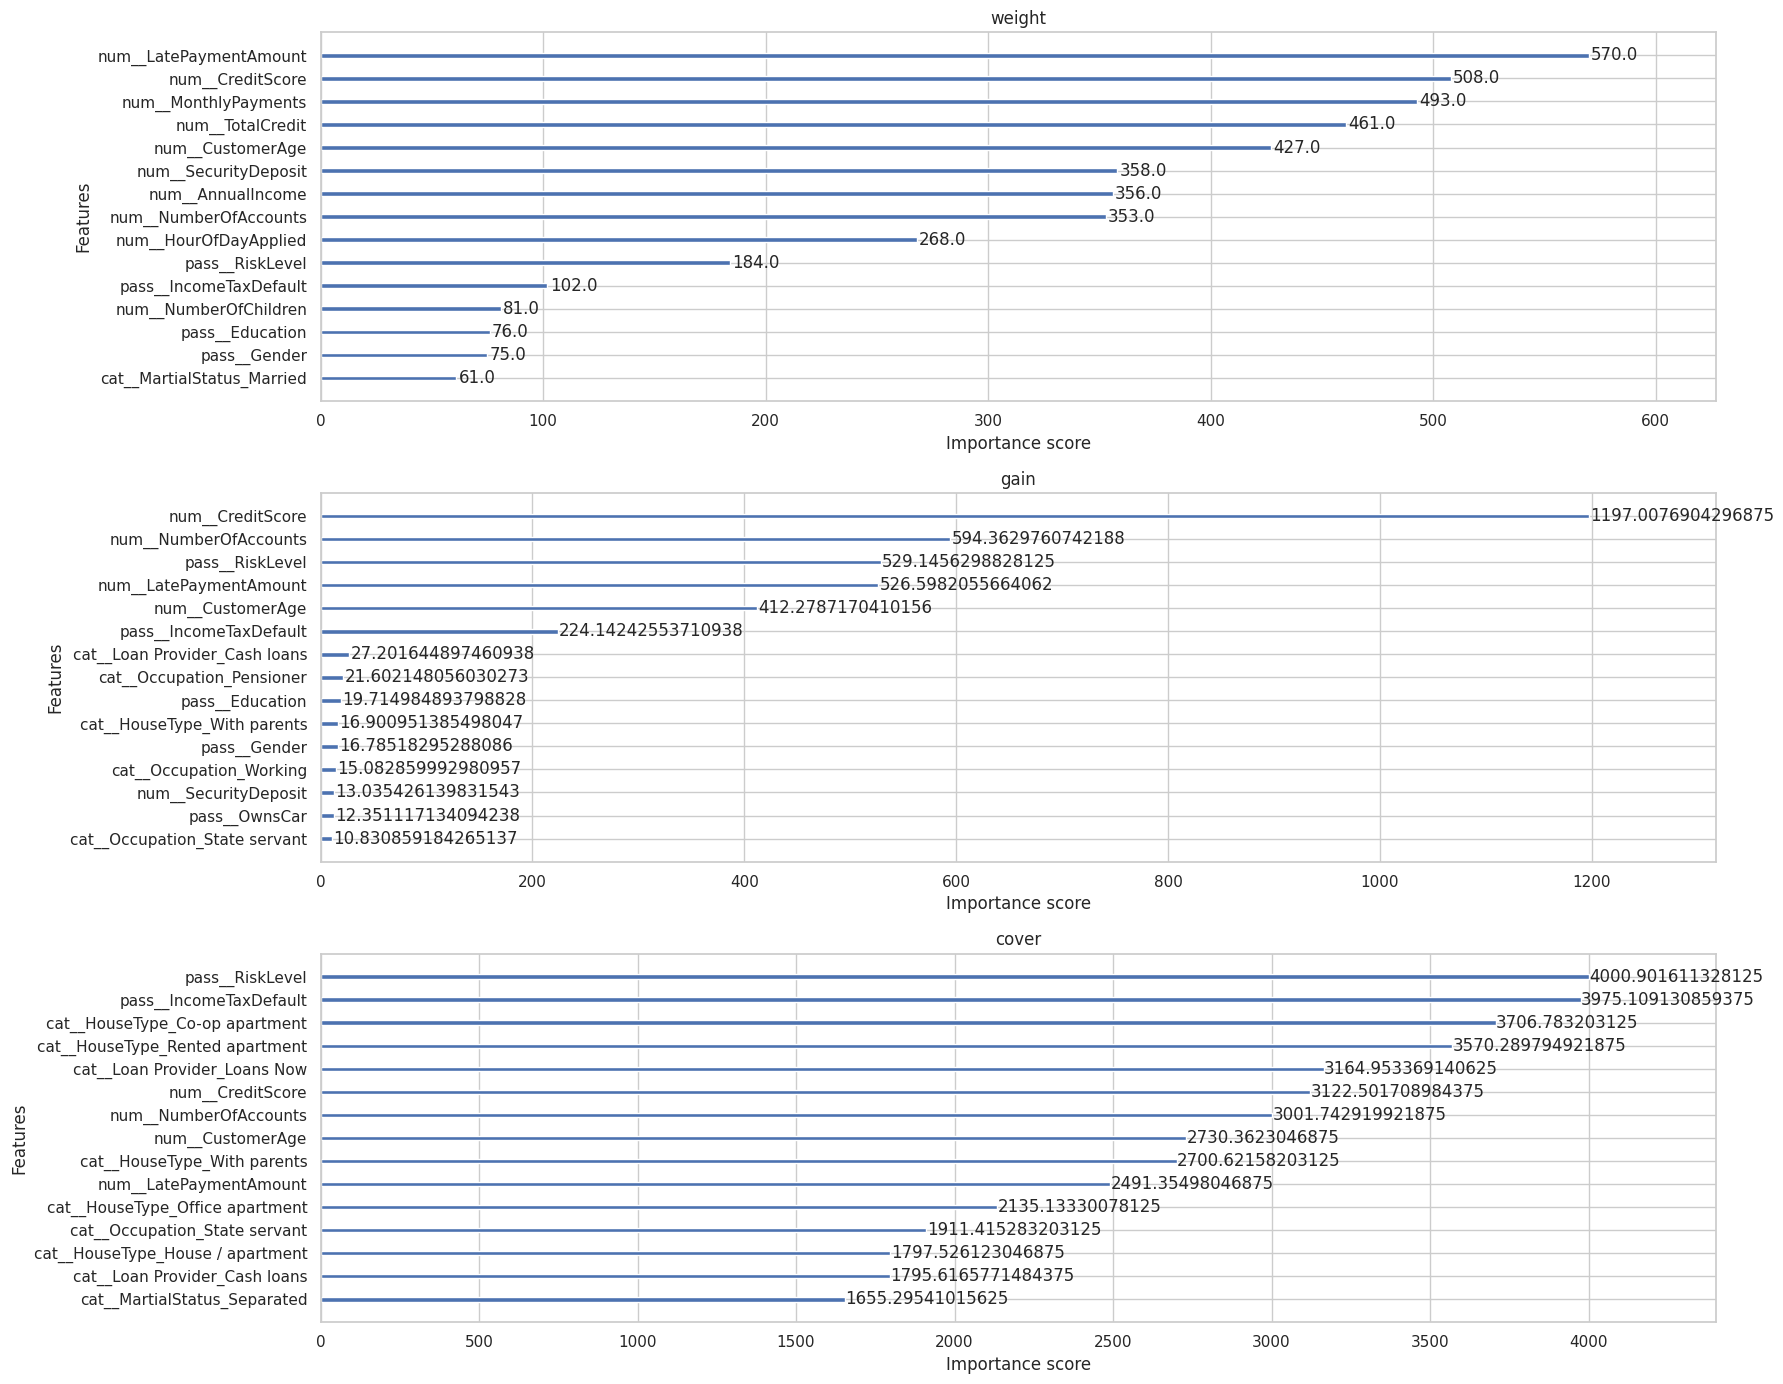

In [ ]:
xgb_step = best_model.named_steps['model']

fig, axes = plt.subplots(3, 1, figsize=(18, 14))

for ax, imp_type in zip(axes, ['weight', 'gain', 'cover']):
    plot_importance(xgb_step, importance_type=imp_type,
                   ax=ax, max_num_features=15, title=imp_type)
plt.tight_layout()
plt.show()

In [ ]:
X_test_proc = best_model[:-1].transform(X_test)

explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_test_proc)

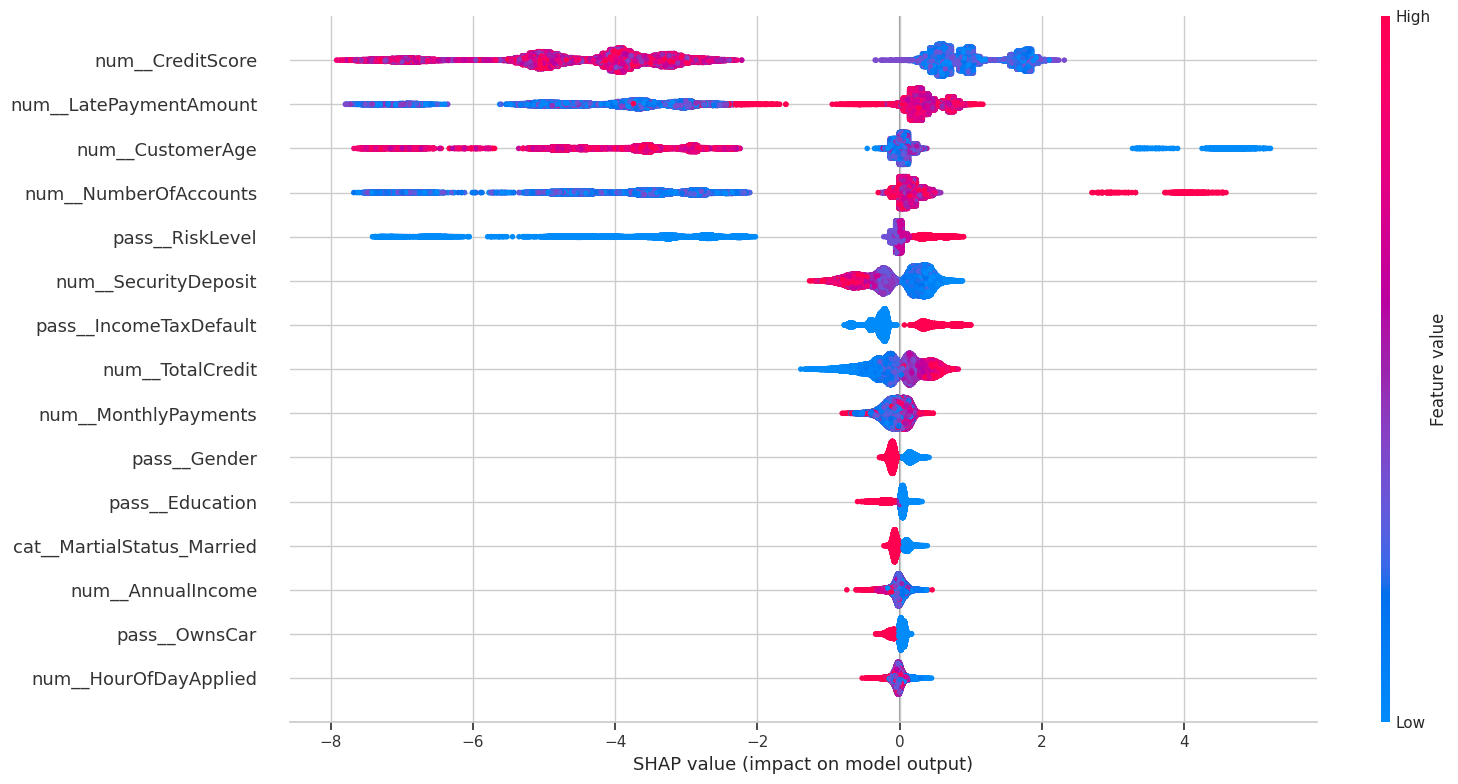

<Figure size 1600x800 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
shap.summary_plot(shap_values, X_test_proc,
                  max_display=15, plot_size=(16, 8))
plt.gcf().set_size_inches(16, 8)
plt.tight_layout()
plt.show()

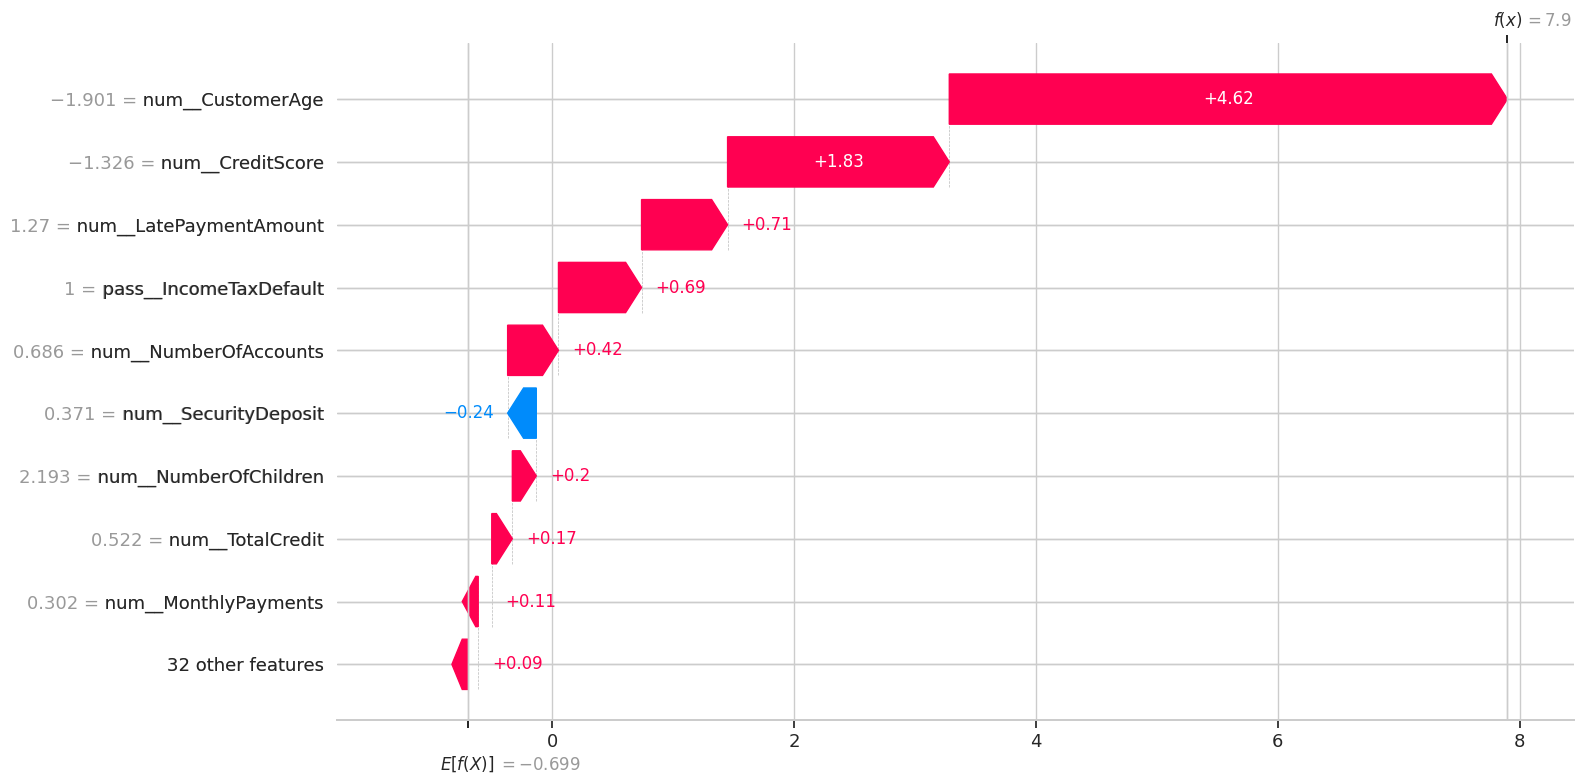

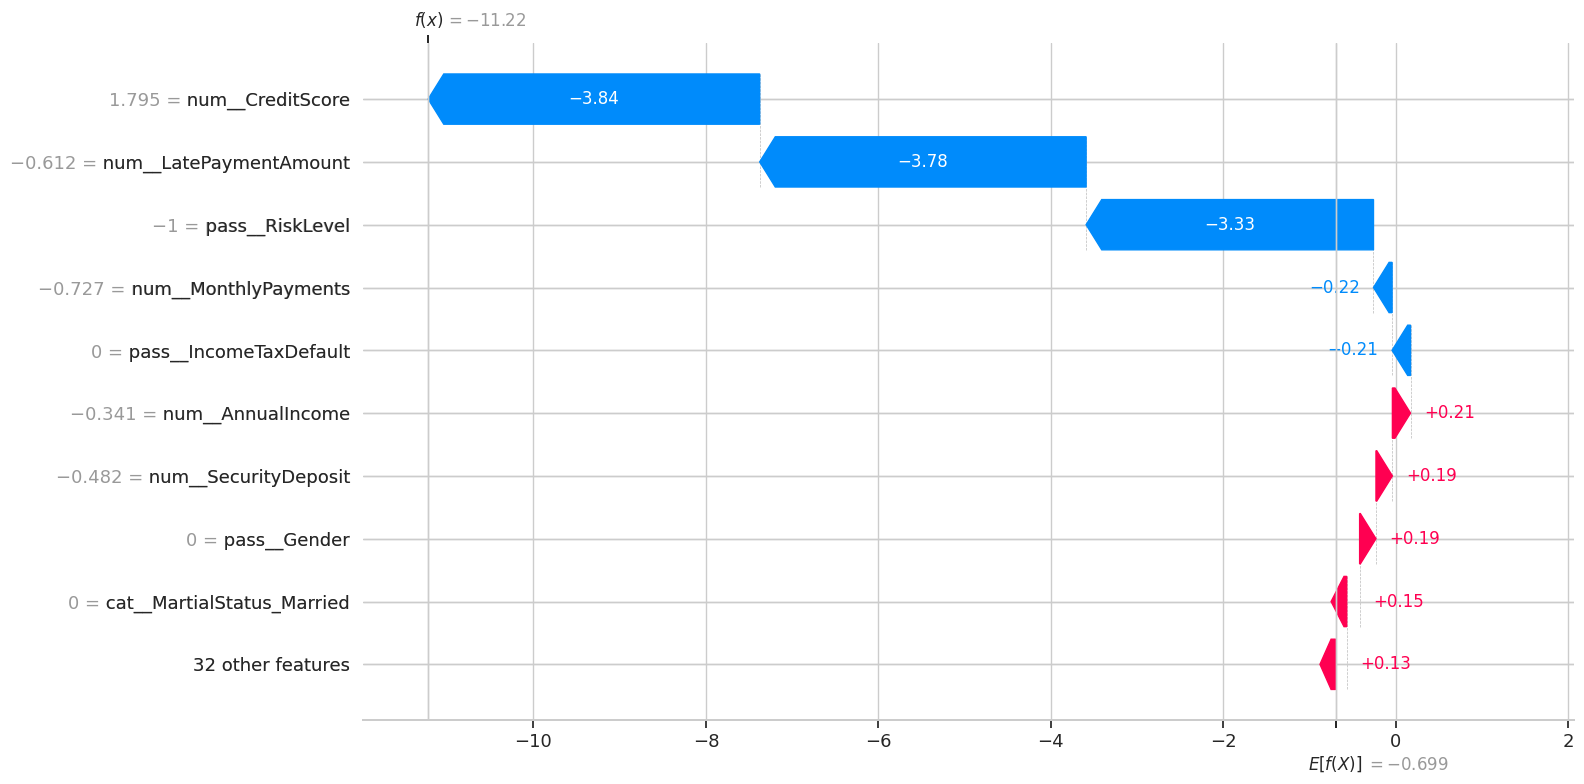

In [ ]:
fraud_idx = X_test[y_test == 1].index[0]
legit_idx = X_test[y_test == 0].index[0]

fraud_proc = best_model[:-1].transform(X_test.loc[[fraud_idx]])
legit_proc = best_model[:-1].transform(X_test.loc[[legit_idx]])

# Fraud waterfall
shap.waterfall_plot(shap.Explanation(
    values=explainer.shap_values(fraud_proc)[0],
    base_values=explainer.expected_value,
    data=fraud_proc.iloc[0],
    feature_names=fraud_proc.columns.tolist()
), show=False)
plt.gcf().set_size_inches(16, 8)
plt.tight_layout()
plt.show()

# No fraud waterfall
shap.waterfall_plot(shap.Explanation(
    values=explainer.shap_values(legit_proc)[0],
    base_values=explainer.expected_value,
    data=legit_proc.iloc[0],
    feature_names=legit_proc.columns.tolist()
), show=False)
plt.gcf().set_size_inches(16, 8)
plt.tight_layout()
plt.show()

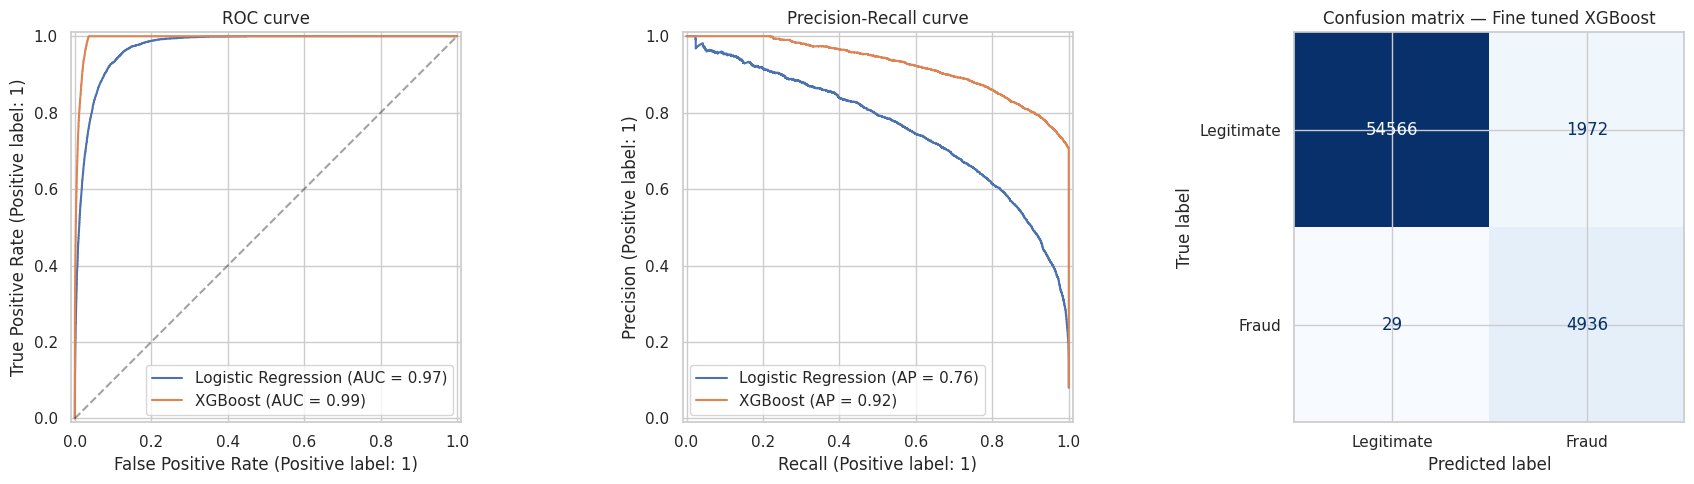

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve — both models on same axes
for name, model in [('Logistic Regression', pipe_lr), ('XGBoost', best_model)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name=name)
axes[0].set_title('ROC curve')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)

# Precision-Recall curve — more honest for imbalanced data
for name, model in [('Logistic Regression', pipe_lr), ('XGBoost', best_model)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=name)
axes[1].set_title('Precision-Recall curve')

# Confusion matrix — XGBoost only
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, ax=axes[2],
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues', colorbar=False
)
axes[2].set_title('Confusion matrix — Fine tuned XGBoost')

plt.tight_layout()
plt.show()

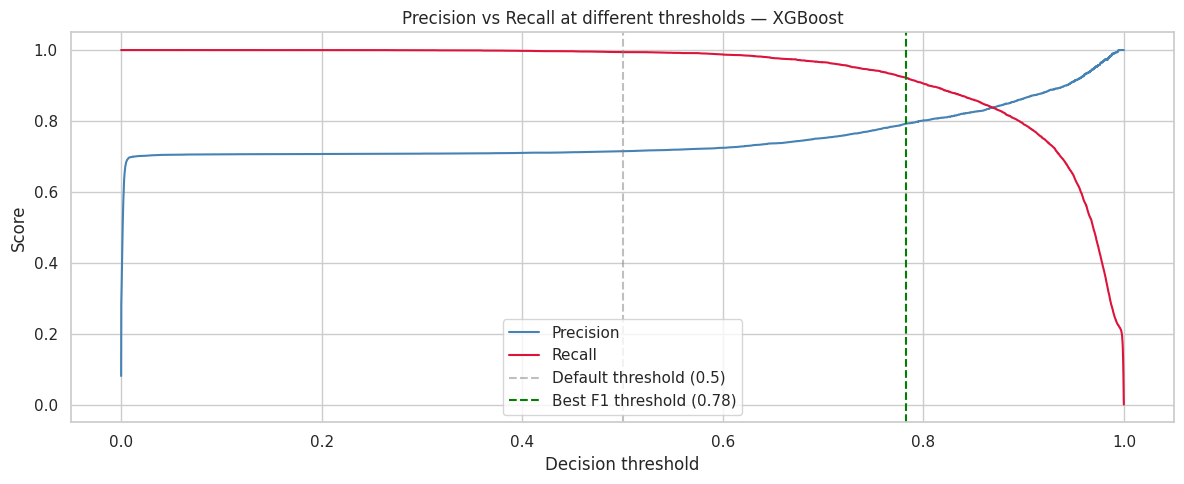

At threshold 0.78:
  Precision: 0.792
  Recall:    0.922
  F1:        0.852


In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='crimson')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')

# Mark the point where precision = recall (optimal F1)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx  = f1_scores.argmax()
plt.axvline(thresholds[best_idx], color='green', linestyle='--',
            label=f'Best F1 threshold ({thresholds[best_idx]:.2f})')

plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at different thresholds — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

print(f"At threshold {thresholds[best_idx]:.2f}:")
print(f"  Precision: {precisions[best_idx]:.3f}")
print(f"  Recall:    {recalls[best_idx]:.3f}")
print(f"  F1:        {f1_scores[best_idx]:.3f}")

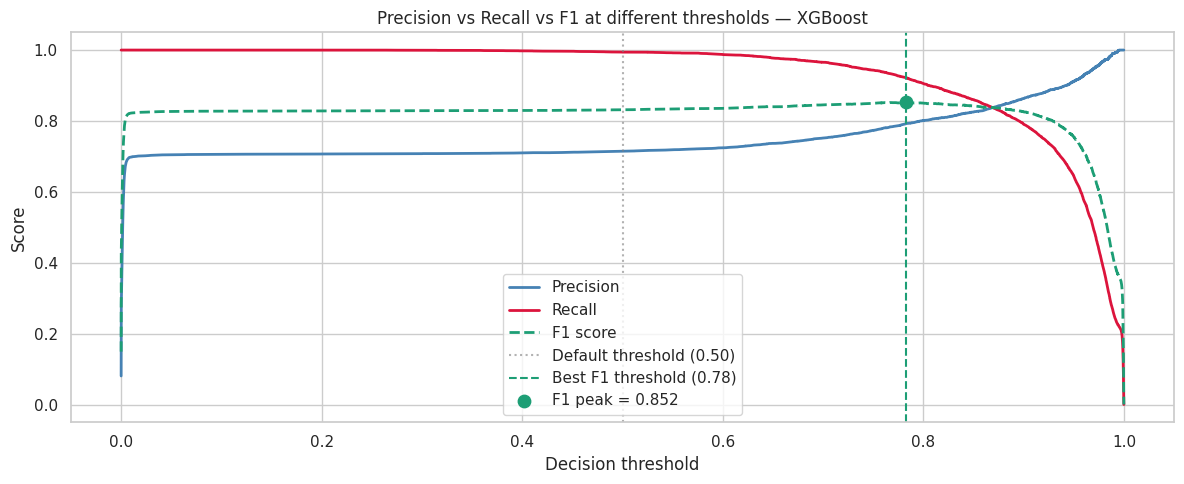

At best F1 threshold 0.78:
  Precision: 0.792
  Recall:    0.922
  F1:        0.852


In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx  = f1_scores.argmax()

plt.figure(figsize=(12, 5))
plt.plot(thresholds, precisions[:-1], label='Precision',  color='steelblue', linewidth=2)
plt.plot(thresholds, recalls[:-1],    label='Recall',     color='crimson',   linewidth=2)
plt.plot(thresholds, f1_scores,       label='F1 score',   color='#1D9E75',   linewidth=2,
         linestyle='--')

plt.axvline(0.5, color='gray',  linestyle=':', alpha=0.6,
            label='Default threshold (0.50)')
plt.axvline(thresholds[best_idx], color='#1D9E75', linestyle='--',
            label=f'Best F1 threshold ({thresholds[best_idx]:.2f})')

# Mark the peak of the F1 curve explicitly
plt.scatter([thresholds[best_idx]], [f1_scores[best_idx]],
            color='#1D9E75', zorder=5, s=80,
            label=f'F1 peak = {f1_scores[best_idx]:.3f}')

plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall vs F1 at different thresholds — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

print(f"At best F1 threshold {thresholds[best_idx]:.2f}:")
print(f"  Precision: {precisions[best_idx]:.3f}")
print(f"  Recall:    {recalls[best_idx]:.3f}")
print(f"  F1:        {f1_scores[best_idx]:.3f}")

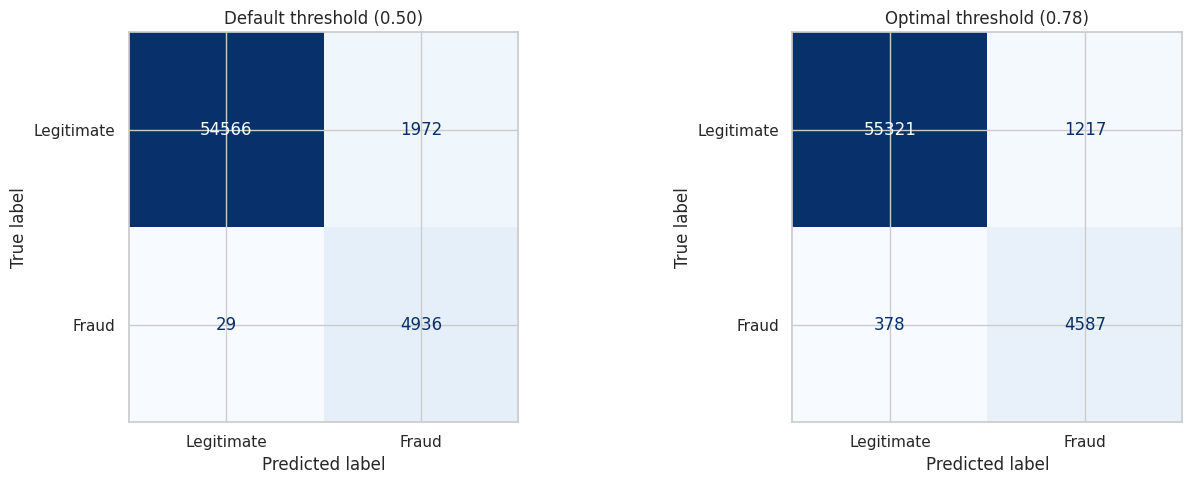

In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_proba >= 0.78).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold 0.50
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    ax=axes[0],
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title('Default threshold (0.50)')

# Optimal threshold 0.78
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_optimal,
    ax=axes[1],
    display_labels=['Legitimate', 'Fraud'],
    cmap='Blues',
    colorbar=False
)
axes[1].set_title('Optimal threshold (0.78)')

plt.tight_layout()
plt.show()

In [ ]:
# Save best model
joblib.dump(best_model, 'fraud_classificator_joblib.joblib')
with open('fraud_classificator_pickle.pkl', 'wb') as f:
    pickle.dump(best_model, f)

-----

### **3. Despliegue**

**Mini prueba con la muestra para generar los decision boundaries**

In [3]:
def filter_cols(df):
  df = df.copy()
  df = df[df['MartialStatus'] != 'Unknown'].reset_index(drop=True)
  df = df[df['Gender'] != 'XNA'].reset_index(drop=True)
  df['Occupation'] = df['Occupation'].replace(['Unemployed', 'Student', 'Businessman', 'Maternity leave'], 'Other')
  df['RiskLevel'] = df['RiskLevel'].fillna('Unknown')
  print(f"Duplicates found: {df.duplicated().sum().sum()}")
  df = df.drop_duplicates()
  X, y = df.drop(columns=['Fraud'], axis=1), df['Fraud']
  return X, y


def map_cols(df):
  df = df.copy()
  risk_order = {'LowRisk': 0, 'Risk': 1, 'HighRisk': 2, 'Unknown': -1}
  edu_order = {'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}
  gender_map = {'M': 0, 'F': 1}
  df['RiskLevel'] = df['RiskLevel'].map(risk_order) # Ordinal Encoder
  df['Education'] = df['Education'].map(edu_order) # Ordinal Encoder
  df['Gender']= df['Gender'].map(gender_map)
  return df


def transform_num_cols(df):
  df = df.copy()
  drop_cols = ['LoanID', 'NumberOfBankAccounts', 'ExperianRating']
  df = df.drop(drop_cols, axis = 1)
  return df

In [4]:
loaded_pipe = joblib.load('/content/fraud_classificator_joblib.joblib')

In [5]:
df = pd.read_csv("/content/FraudData (March 2026).xlsx - FraudData.csv")
# random subsample
df_sample = df.sample(n=30000, random_state=71)
df_sample['Fraud'].value_counts()

,count
Fraud,
0,27564
1,2436


In [9]:
df_fast = pd.read_csv("/content/sample.csv")
# Drop Fraud column
df_fast = df_fast.drop('Fraud', axis=1)
df_fast.head()
df_fast.to_csv('sample_notarget.csv', index=False)

In [ ]:
X_test, y_test = filter_cols(df_sample)

Duplicates found: 0


In [ ]:
y_pred_test_bm = loaded_pipe.predict(X_test)
y_pred_test_bm

array([0, 1, 0, ..., 0, 0, 0])

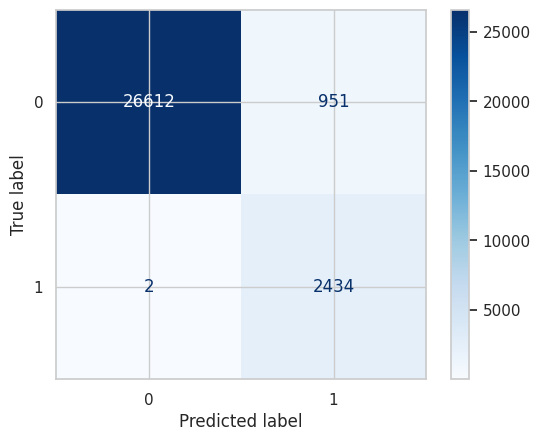

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_bm, cmap='Blues')
plt.show()

In [ ]:
y_proba = loaded_pipe.predict_proba(X_test)[:, 1]
LOW_THRESHOLD  = 0.50
HIGH_THRESHOLD = 0.78

def assign_zone(prob):
    if prob < LOW_THRESHOLD:
        return 'AUTO_APPROVE'
    elif prob < HIGH_THRESHOLD:
        return 'HUMAN_REVIEW'
    else:
        return 'AUTO_REJECT'

results = pd.DataFrame({
    'probability': y_proba,
    'predicted_fraud': (y_proba >= HIGH_THRESHOLD).astype(int),
    'true_label':  y_test.values,
    'zone':        [assign_zone(p) for p in y_proba]
}, index=X_test.index)

# filter to review cases only
review_queue = results[results['zone'] == 'HUMAN_REVIEW'].copy()
review_queue = review_queue.sort_values('probability', ascending=False)

print(f"Total applications: {len(results):,}")
print(f"Auto approved: {(results['zone']=='AUTO_APPROVE').sum():,}")
print(f"Sent to human review: {(results['zone']=='HUMAN_REVIEW').sum():,}")
print(f"Auto rejected: {(results['zone']=='AUTO_REJECT').sum():,}")

print(f"\nActually legit: {(review_queue['true_label']==0).sum():,} false positives to clear")
print(f"Actually fraud: {(review_queue['true_label']==1).sum():,} fraud caught by review")


review_with_data = X_test.loc[review_queue.index].copy()
review_with_data['fraud_probability'] = review_queue['probability']
review_with_data['zone'] = review_queue['zone']
review_with_data['true_label'] = review_queue['true_label']  # only available in testing

review_with_data = review_with_data.sort_values('fraud_probability', ascending=False)

display(review_with_data.head())

Total applications: 29,999
Auto approved: 26,614
Sent to human review: 533
Auto rejected: 2,852

Actually legit: 395 false positives to clear
Actually fraud: 138 fraud caught by review


,LoanID,Loan Provider,Gender,OwnsCar,OwnsProperty,NumberOfChildren,AnnualIncome,TotalCredit,MonthlyPayments,SecurityDeposit,...,CreditScore,CustomerAge,IncomeTaxDefault,NumberOfBankAccounts,ApplicationDay,HourOfDayApplied,ExperianRating,fraud_probability,zone,true_label
16548,257247,Loans Now,M,1,0,1,450000.0,900000.0,45000.0,900000.0,...,164,36,1,17,MONDAY,15,222.2,0.779458,HUMAN_REVIEW,1
16791,238092,Cash loans,F,0,1,0,180000.0,390960.0,23755.5,337500.0,...,290,36,0,24,TUESDAY,13,323.0,0.778345,HUMAN_REVIEW,1
26523,264419,Cash loans,F,0,1,1,135000.0,770292.0,30676.5,688500.0,...,121,32,0,17,THURSDAY,7,187.8,0.778107,HUMAN_REVIEW,0
29344,249009,Loans Now,F,0,1,2,450000.0,900000.0,45000.0,900000.0,...,144,51,1,18,SATURDAY,10,206.2,0.778099,HUMAN_REVIEW,1
15300,135697,Loans Now,F,1,1,1,157500.0,135000.0,6750.0,135000.0,...,226,37,0,20,THURSDAY,10,271.8,0.777848,HUMAN_REVIEW,1


- **Repo:** https://github.com/nicolastibata/MINE_4206_AML_202610/tree/main/labs/lab_4/fraud_detection_app
- **Despliegue:** https://fraud-detection-aml-202610.streamlit.app/
